<a href="https://www.kaggle.com/code/sofiatanganho/3-0-interpretacao-ipynb?scriptVersionId=320414207" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Análise Preditiva do Mercado Imobiliário de Boston
#### Grupo 10: Diana Figueiredo, Natacha Zhang, Sofia Tanganho
#### Docente: Dora Melo

## Importação de Bibliotecas
(Diana Figueiredo)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from scipy.stats import kstest, norm

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split,
    KFold,
    ParameterGrid,
    GridSearchCV,           
    RandomizedSearchCV,    
    cross_validate,        
    learning_curve          
)
from sklearn.pipeline import Pipeline                  
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,    
    davies_bouldin_score        
)
from xgboost import XGBRegressor
from sklearn.utils import resample

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/natachazhang/dados-processados/boston_processed.csv


## Carregamento do Dataset Processado
(Diana Figueiredo)

In [3]:
df = pd.read_csv("/kaggle/input/datasets/natachazhang/dados-processados/boston_processed.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ZN          506 non-null    float64
 1   INDUS       506 non-null    float64
 2   CHAS        506 non-null    int64  
 3   AGE         506 non-null    float64
 4   TAX         506 non-null    float64
 5   B           506 non-null    float64
 6   MEDV        506 non-null    float64
 7   B_stand     506 non-null    float64
 8   ZN_stand    506 non-null    float64
 9   INDUS_norm  506 non-null    float64
 10  AGE_norm    506 non-null    float64
 11  TAX_norm    506 non-null    float64
 12  IQV         506 non-null    float64
 13  IAH         506 non-null    float64
 14  IQV_stand   506 non-null    float64
 15  IAH_stand   506 non-null    float64
dtypes: float64(15), int64(1)
memory usage: 63.4 KB


## 1. Problema Supervisionado - Regressão
(Diana Figueiredo)

### 1.1. Divisão do Dataset e Definição das Variáveis

In [4]:
X = df[[
    'ZN_stand',      
    'INDUS_norm',    
    'CHAS',          
    'AGE_norm',      
    'TAX_norm',      
    'B_stand',       
    'IQV_stand',   
    'IAH_stand'      
]]

y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (354, 8)
Teste: (152, 8)


### 1.2. Modelo Final - Random Forest

Após comparação entre Regressão Linear (_baseline_), Random Forest, XGBoost e SVR, e otimização via _GridSearchCV_ (5-fold), o **Random Forest** foi selecionado como modelo final por apresentar o melhor equilíbrio entre desempenho e capacidade de generalização. Os hiperparâmetros por omissão (`n_estimators=100`, `max_depth=None`, `min_samples_split=2`) revelaram-se já ótimos.

In [5]:
param_grid_rf = {
    'n_estimators':      [100, 200, 300,400],
    'max_depth':         [None,5, 10, 15],
    'min_samples_split': [2, 5, 10],
}

gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf, cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)

gs_rf.fit(X_train, y_train)

rf_tuned        = gs_rf.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)
rmse_rf_tuned   = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned    = mean_absolute_error(y_test, y_pred_rf_tuned)
r2_rf_tuned     = r2_score(y_test, y_pred_rf_tuned)

print('Randon Forest — Melhores hiperparâmetros:', gs_rf.best_params_)
print(f'  RMSE Teste (otimizado): {rmse_rf_tuned:.4f}')
print(f'  MAE  Teste (otimizado): {mae_rf_tuned:.4f}')
print(f'  R²   Teste (otimizado): {r2_rf_tuned:.4f}')

Randon Forest — Melhores hiperparâmetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  RMSE Teste (otimizado): 3.5936
  MAE  Teste (otimizado): 2.5627
  R²   Teste (otimizado): 0.8267


### 1.3. Análise de Resíduos
(Sofia Tanganho)

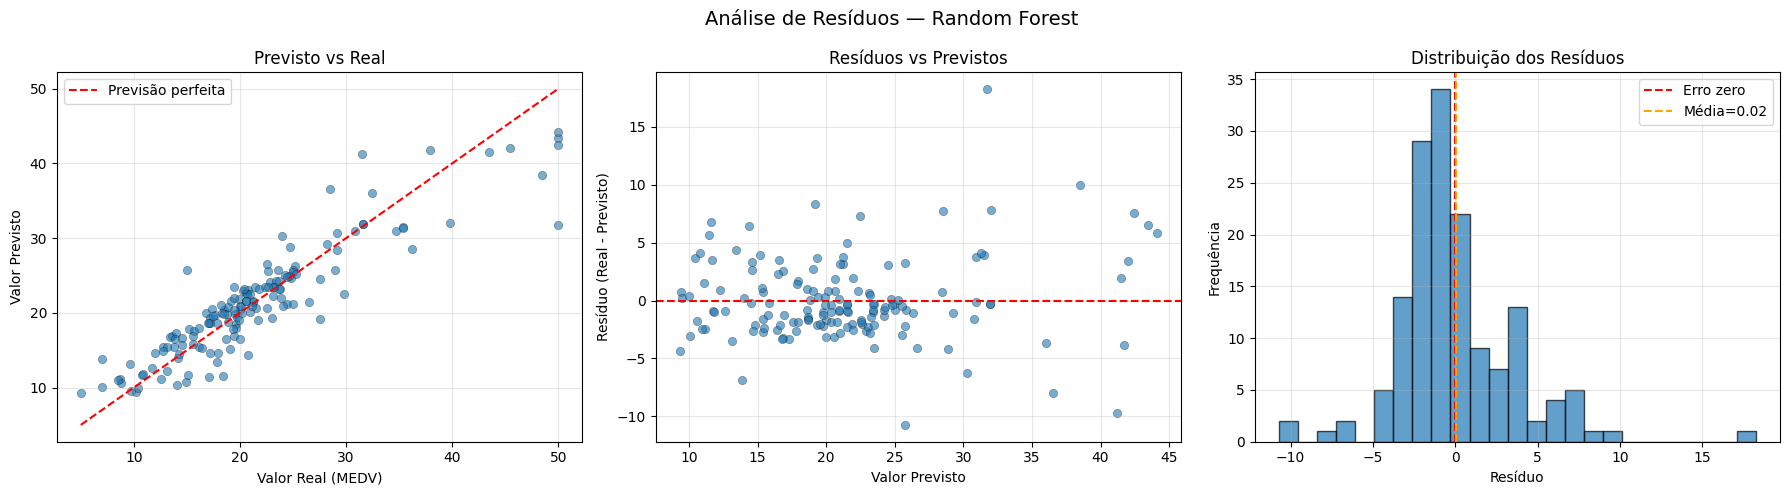


Estatísticas dos Resíduos — Random Forest 
  Resíduo médio  : 0.0244 
  Desvio padrão  : 3.5935
  Erro máximo    : 18.2760
  Erro mínimo    : -10.7300
  % casos |erro| < 2k$: 51.3%
  % casos |erro| < 5k$: 88.8%

Top 10 piores previsões:
     MEDV_real  MEDV_previsto  Erro_abs
371       50.0         31.724    18.276
375       15.0         25.730    10.730
203       48.5         38.500    10.000
229       31.5         41.213     9.713
409       27.5         19.181     8.319
290       28.5         36.517     8.017
180       39.8         31.981     7.819
181       36.2         28.484     7.716
225       50.0         42.432     7.568
473       29.8         22.494     7.306


In [6]:
nome_modelo_final = 'Random Forest '
y_pred_final      = y_pred_rf_tuned
residuos          = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Previsto vs Real
axes[0].scatter(y_test, y_pred_final, alpha=0.6, edgecolors='k', linewidths=0.3)
lim = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lim, lim, 'r--', label='Previsão perfeita')
axes[0].set_xlabel('Valor Real (MEDV)')
axes[0].set_ylabel('Valor Previsto')
axes[0].set_title('Previsto vs Real')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Resíduos vs Previstos
axes[1].scatter(y_pred_final, residuos, alpha=0.6, edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Valor Previsto')
axes[1].set_ylabel('Resíduo (Real - Previsto)')
axes[1].set_title('Resíduos vs Previstos')
axes[1].grid(True, alpha=0.3)

# Distribuição dos Resíduos
axes[2].hist(residuos, bins=25, edgecolor='k', alpha=0.7)
axes[2].axvline(0, color='r', linestyle='--', label='Erro zero')
axes[2].axvline(residuos.mean(), color='orange', linestyle='--',
                label=f'Média={residuos.mean():.2f}')
axes[2].set_xlabel('Resíduo')
axes[2].set_ylabel('Frequência')
axes[2].set_title('Distribuição dos Resíduos')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Análise de Resíduos — {nome_modelo_final}', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nEstatísticas dos Resíduos — {nome_modelo_final}')
print(f'  Resíduo médio  : {residuos.mean():.4f} ')
print(f'  Desvio padrão  : {residuos.std():.4f}')
print(f'  Erro máximo    : {residuos.max():.4f}')
print(f'  Erro mínimo    : {residuos.min():.4f}')
print(f'  % casos |erro| < 2k$: {(np.abs(residuos) < 2).mean()*100:.1f}%')
print(f'  % casos |erro| < 5k$: {(np.abs(residuos) < 5).mean()*100:.1f}%')

df_erros = X_test.copy()
df_erros['MEDV_real']     = y_test.values
df_erros['MEDV_previsto'] = y_pred_final
df_erros['Erro_abs']      = np.abs(residuos)
df_erros = df_erros.sort_values('Erro_abs', ascending=False)

print('\nTop 10 piores previsões:')
print(df_erros[['MEDV_real', 'MEDV_previsto', 'Erro_abs']].head(10).to_string())

#### Conclusões:
O resíduo médio próximo de zero confirma ausência de enviesamento sistemático. O gráfico **Previsto vs Real** mostra maior dispersão para valores elevados de `MEDV`, indicando maior dificuldade em prever habitações de topo de gama. Os erros são maioritariamente aleatórios, com 51.3% das previsões abaixo de 2k$ de erro e 88.8% abaixo de 5k$.

### 1.5. Importância das Variáveis

Importância de Variáveis:
   Feature  Random Forest
 IAH_stand       0.590397
 IQV_stand       0.116766
  AGE_norm       0.083127
INDUS_norm       0.077707
  TAX_norm       0.059965
   B_stand       0.049034
  ZN_stand       0.017987
      CHAS       0.005017


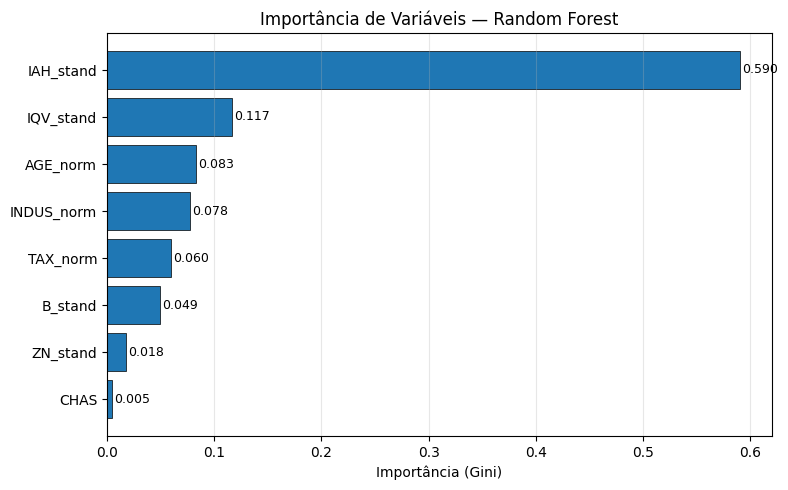

In [7]:
feature_names = [
    'ZN_stand', 'INDUS_norm', 'CHAS', 'AGE_norm',
    'TAX_norm', 'B_stand', 'IQV_stand', 'IAH_stand'
]

importancias_rf = rf_tuned.feature_importances_

df_imp = pd.DataFrame({
    'Feature':       feature_names,
    'Random Forest': importancias_rf,
}).sort_values('Random Forest', ascending=False)

print('Importância de Variáveis:')
print(df_imp.to_string(index=False))

df_plot = df_imp.sort_values('Random Forest', ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(df_plot['Feature'], df_plot['Random Forest'], edgecolor='k', linewidth=0.5)
ax.set_title('Importância de Variáveis — Random Forest', fontsize=12)
ax.set_xlabel('Importância (Gini)')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, df_plot['Random Forest']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()



#### Conclusões:

O `IAH_stand` é a variável mais determinante (59%), confirmando que o rácio entre atratividade habitacional e penalização socioeconómica concentra a maior parte da informação preditiva. O `IQV_stand` surge em segundo lugar (11.7%), seguido de `AGE_norm` (8.3%) e `INDUS_norm` (7.8%). As variáveis `ZN_stand` (1.8%) e `CHAS` (0.5%) têm importância residual.

## 2. Problema Não Supervisionado - Clustering
(Natacha Zhang)

### 2.1. Preparação dos Dados

In [8]:
features_cluster = ['CHAS', 'B_stand', 'ZN_stand', 'INDUS_norm', 'AGE_norm', 'TAX_norm', 'IQV_stand', 'IAH_stand']
X_cluster = df[features_cluster]

X_cl_train, X_cl_test = train_test_split(X_cluster, test_size=0.30, random_state=42)
print(f'Treino: {X_cl_train.shape[0]} | Teste: {X_cl_test.shape[0]}')

Treino: 354 | Teste: 152


### 2.2. Escolha do k- Método do Cotovelo e Silhouette

Análise exploratória para fundamentar a seleção do número de clusters, validada pelo critério do Objetivo SMART 2 (Silhouette > 0.50).

ELBOW / SILHOUETTE (KMEANS)
 k     inertia  silhouette
 2 1103.333518    0.447582
 3  813.344666    0.505966
 4  527.739657    0.554541
 5  436.764997    0.337227
 6  360.573948    0.386602
 7  335.008470    0.336393
 8  317.092325    0.316973
 9  276.099836    0.318110
10  241.495582    0.331603

Melhor k pelo Silhouette Score: 4 (score=0.5545)


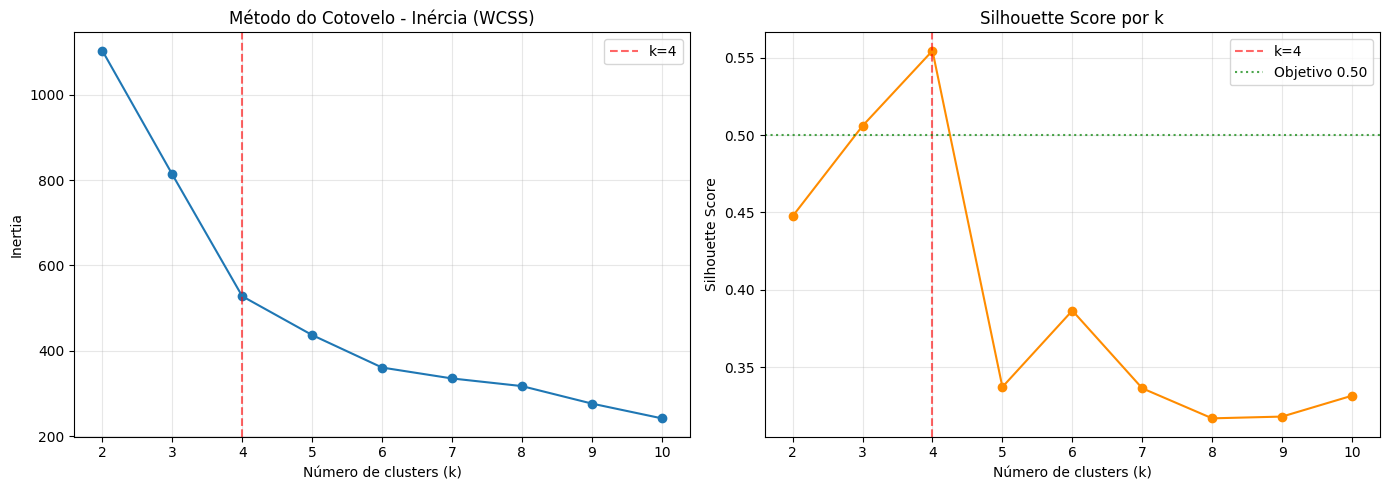

In [9]:
def safe_silhouette(X, labels):
    unique = np.unique(labels)
    if len(unique) < 2:
        return np.nan
    return silhouette_score(X, labels)

k_values = range(2, 11)
elbow_rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_cl_train)
    elbow_rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": safe_silhouette(X_cl_train, labels)
    })

elbow_df = pd.DataFrame(elbow_rows)
best_k = int(elbow_df.loc[elbow_df["silhouette"].idxmax(), "k"])
best_k_sil = elbow_df["silhouette"].max()

print("ELBOW / SILHOUETTE (KMEANS)")
print(elbow_df.to_string(index=False))
print(f"\nMelhor k pelo Silhouette Score: {best_k} (score={best_k_sil:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(elbow_df["k"], elbow_df["inertia"], marker="o")
axes[0].axvline(best_k, linestyle="--", color="red", alpha=0.6, label=f"k={best_k}")
axes[0].set_title("Método do Cotovelo - Inércia (WCSS)")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(elbow_df["k"], elbow_df["silhouette"], marker="o", color="darkorange")
axes[1].axvline(best_k, linestyle="--", color="red", alpha=0.6, label=f"k={best_k}")
axes[1].axhline(0.50, linestyle=":", color="green", alpha=0.7, label="Objetivo 0.50")
axes[1].set_title("Silhouette Score por k")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3. Modelo Final - Agglomerative Clustering

Após comparação entre _KMeans_, _Agglomerative Clustering_ e _DBSCAN_, e otimização via _ParameterGrid_ (linkage × n_clusters), o **Agglomerative Clustering com `linkage='complete'` e `n_clusters=2`** foi selecionado como modelo final por apresentar a Silhouette mais elevada no teste (0.74), sem pontos de ruído e com clusters estáveis e interpretáveis.

In [10]:
agg_final = AgglomerativeClustering(n_clusters=2, linkage='complete', metric='euclidean')

labels_train_final = agg_final.fit_predict(X_cl_train)
labels_test_final  = AgglomerativeClustering(n_clusters=2, linkage='complete', metric='euclidean').fit_predict(X_cl_test)

print('Agglomerative Clustering Final ')
print(f'Silhouette Treino : {silhouette_score(X_cl_train, labels_train_final):.4f}')
print(f'Silhouette Teste  : {silhouette_score(X_cl_test,  labels_test_final):.4f}')
print(f'CH Treino         : {calinski_harabasz_score(X_cl_train, labels_train_final):.4f}')
print(f'CH Teste          : {calinski_harabasz_score(X_cl_test,  labels_test_final):.4f}')
print(f'DB Treino         : {davies_bouldin_score(X_cl_train, labels_train_final):.4f}')
print(f'DB Teste          : {davies_bouldin_score(X_cl_test,  labels_test_final):.4f}')

Agglomerative Clustering Final 
Silhouette Treino : 0.5889
Silhouette Teste  : 0.7363
CH Treino         : 84.7915
CH Teste          : 21.4427
DB Treino         : 0.7157
DB Teste          : 0.1781


### 2.4. Estabilidade- Bootstrap (30 iterações)
(Diana Figueiredo)

In [11]:
silhouettes_bootstrap = []

for _ in range(30):
    X_boot = resample(X_cluster, random_state=None)
    labels_boot = AgglomerativeClustering(n_clusters=2, linkage='complete', metric='euclidean').fit_predict(X_boot)
    if len(set(labels_boot)) > 1:
        silhouettes_bootstrap.append(silhouette_score(X_boot, labels_boot))

ci_low  = np.percentile(silhouettes_bootstrap, 2.5)
ci_high = np.percentile(silhouettes_bootstrap, 97.5)

print('Bootstrap (30 iterações)')
print(f'Silhouette média : {np.mean(silhouettes_bootstrap):.4f}')
print(f'Desvio padrão    : {np.std(silhouettes_bootstrap):.4f}')
print(f'IC 95%           : [{ci_low:.3f}, {ci_high:.4f}]')

Bootstrap (30 iterações)
Silhouette média : 0.6471
Desvio padrão    : 0.0819
IC 95%           : [0.541, 0.7571]


#### Conclusões:
O intervalo de confiança a 95% confirma que o critério SMART é cumprido independentemente da amostra utilizada, garantindo robustez e estabilidade do modelo final.

### 2.5. Caracterização dos Clusters
(Diana Figueiredo)

In [12]:
df['Cluster'] = AgglomerativeClustering(n_clusters=2, linkage='complete', metric='euclidean').fit_predict(X_cluster)

cols_caract = ['ZN', 'INDUS', 'CHAS', 'AGE', 'TAX', 'B', 'IQV', 'IAH', 'MEDV']

print(' Distribuição dos Clusters ')
print(df['Cluster'].value_counts().to_string())
print()
print('Perfil Médio por Cluster')
print(df.groupby('Cluster')[cols_caract].mean().round(2).to_string())

 Distribuição dos Clusters 
Cluster
0    487
1     19

Perfil Médio por Cluster
            ZN  INDUS  CHAS    AGE     TAX       B    IQV   IAH   MEDV
Cluster                                                               
0         8.78  11.49  0.07  70.00  413.03  355.40   9.25  0.22  22.14
1        77.66   2.15  0.05  32.06  285.47  389.27  74.05  0.23  32.51


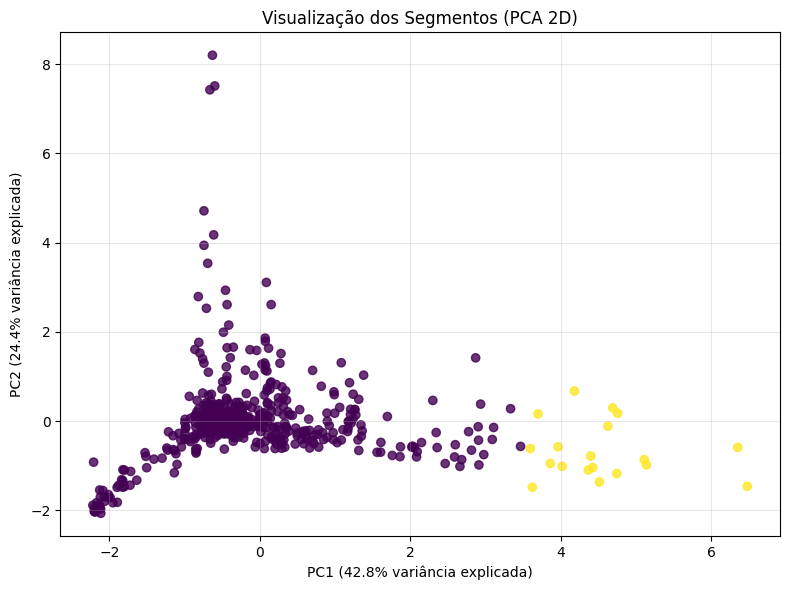

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], alpha=0.8)
plt.title("Visualização dos Segmentos (PCA 2D)")
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância explicada)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância explicada)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

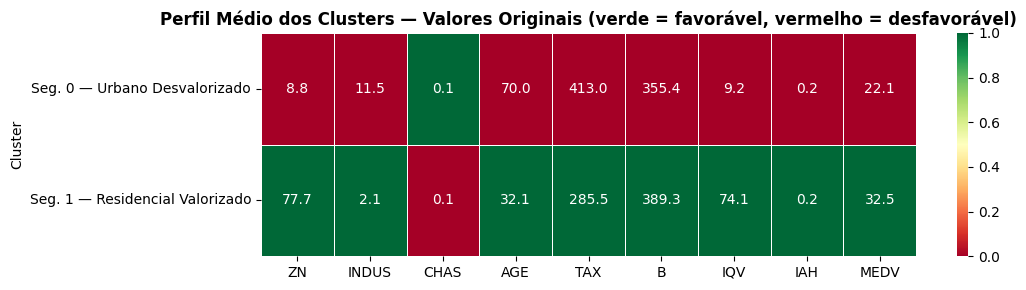

In [14]:
perfil = df.groupby('Cluster')[cols_caract].mean()

cols_inverter = ['INDUS', 'AGE', 'TAX']
cols_diretas  = ['ZN', 'CHAS', 'B', 'IQV', 'IAH', 'MEDV']

perfil_norm = perfil.copy().astype(float)
for col in cols_diretas:
    col_min, col_max = perfil[col].min(), perfil[col].max()
    perfil_norm[col] = (perfil[col] - col_min) / (col_max - col_min) if col_max != col_min else 0.5
for col in cols_inverter:
    col_min, col_max = perfil[col].min(), perfil[col].max()
    perfil_norm[col] = 1 - ((perfil[col] - col_min) / (col_max - col_min)) if col_max != col_min else 0.5

plt.figure(figsize=(11, 3))
sns.heatmap(
    perfil_norm,
    annot=perfil.round(1),
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    vmin=0, vmax=1,
    yticklabels=['Seg. 0 — Urbano Desvalorizado', 'Seg. 1 — Residencial Valorizado']
)
plt.title('Perfil Médio dos Clusters — Valores Originais (verde = favorável, vermelho = desfavorável)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 800x500 with 0 Axes>

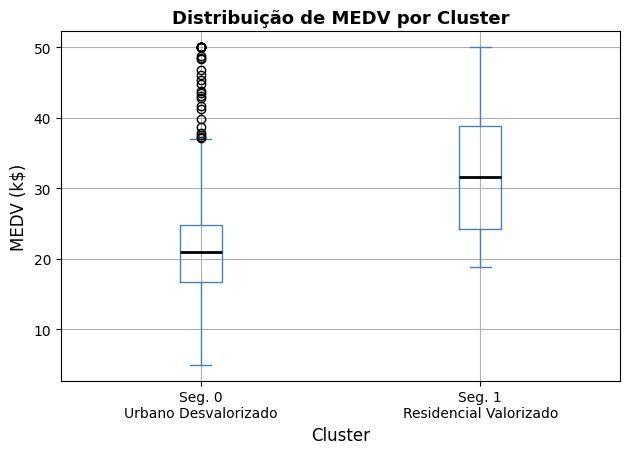

In [15]:
plt.figure(figsize=(8, 5))
df.boxplot(column='MEDV', by='Cluster',
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='black', linewidth=2),
           whiskerprops=dict(color='steelblue'),
           capprops=dict(color='steelblue'))
plt.suptitle('')
plt.title('Distribuição de MEDV por Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('MEDV (k$)', fontsize=12)
plt.xticks([1, 2], ['Seg. 0\nUrbano Desvalorizado', 'Seg. 1\nResidencial Valorizado'])
plt.tight_layout()
plt.savefig('medv_por_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

#### Conclusões:
O **Segmento 0 - Zona Urbana Desvalorizada** (487 observações) agrupa habitações mais antigas (AGE≈70), em zonas industriais (INDUS≈11.5), com maior carga fiscal (TAX≈413) e baixo índice de qualidade de vida (IQV≈9.25). O **Segmento 1 - Zona Residencial Valorizada** (19 observações) representa habitações mais recentes (AGE≈32), em zonas residenciais amplas (ZN≈77.7), com menor industrialização (INDUS≈2.15) e índice de qualidade de vida substancialmente superior (IQV≈74.05).

## 3. Resposta às Perguntas de Investigação
(Sofia Tanganho)

### PI 1 - Que perfis distintos de habitações identifica o modelo de clustering?

In [16]:
print(' Perfil Comparativo dos Segmentos ')
print(df.groupby('Cluster')[['ZN', 'INDUS', 'AGE', 'TAX', 'IQV', 'IAH', 'MEDV']].mean().round(2).to_string())

 Perfil Comparativo dos Segmentos 
            ZN  INDUS    AGE     TAX    IQV   IAH   MEDV
Cluster                                                 
0         8.78  11.49  70.00  413.03   9.25  0.22  22.14
1        77.66   2.15  32.06  285.47  74.05  0.23  32.51


#### Conclusões:
Os dois segmentos são claramente distintos em todas as variáveis chave. O Segmento 0 representa bairros urbanos densos com habitações antigas e degradadas; o Segmento 1 representa bairros residenciais de qualidade com habitações mais recentes e melhores condições de vida. O MEDV médio é substancialmente superior no Segmento 1, confirmando a relevância prática da segmentação.

### PI 2 - Relação entre `LSTAT` (via IAH) e `MEDV`

In [17]:
df_imp_rank = df_imp.reset_index(drop=True).copy()
df_imp_rank['Ranking'] = df_imp_rank.index + 1
df_imp_rank['Importância (%)'] = df_imp_rank['Random Forest'] * 100
corr_iah_medv = df['IAH_stand'].corr(df['MEDV'])
imp_iah = df_imp_rank.loc[df_imp_rank['Feature'] == 'IAH_stand','Importância (%)'].iloc[0]
rank_iah = df_imp_rank.loc[ df_imp_rank['Feature'] == 'IAH_stand','Ranking'].iloc[0]
print(f'Correlação entre IAH_stand e MEDV: {corr_iah_medv:.4f}')
print(f'Importância do IAH_stand no Random Forest: {imp_iah:.1f}%')
print(f'Ranking do IAH_stand no modelo: {int(rank_iah)}.º lugar')
print()

Correlação entre IAH_stand e MEDV: 0.6550
Importância do IAH_stand no Random Forest: 59.0%
Ranking do IAH_stand no modelo: 1.º lugar



#### Observações:
O `IAH` representa a atratividade habitacional, combinando o número médio de divisões a percentagem de população com estatuto socioeconómico mais baixo e a distância aos centros de emprego.Como `LSTAT` está no denominador do `IAH`, valores mais elevados de `LSTAT` tendem a reduzir o valor do índice.
A correlação positiva entre `IAH_stand` e `MEDV` indica que bairros com maior atratividade habitacional tendem a apresentar valores medianos de habitação mais elevados. Assim, o perfil socioeconómico do bairro, representado indiretamente por tem influência relevante na explicação do preço das habitações.

### PI 3- A taxa de criminalidade (`CRIM`) é um preditor relevante?

In [18]:
df_imp_rank = df_imp.reset_index(drop=True).copy()
df_imp_rank['Ranking'] = df_imp_rank.index + 1
df_imp_rank['Importância (%)'] = df_imp_rank['Random Forest'] * 100

corr_iqv_medv = df["IQV_stand"].corr(df["MEDV"])

imp_iqv = df_imp_rank.loc[
    df_imp_rank['Feature'] == 'IQV_stand',
    'Importância (%)'
].iloc[0]

rank_iqv = df_imp_rank.loc[
    df_imp_rank['Feature'] == 'IQV_stand',
    'Ranking'
].iloc[0]

print('CRIM foi incorporada no IQV (Índice de Qualidade de Vida: 1/CRIM + 1/NOX + 1/PTRATIO).')
print(f'Correlação IQV_stand com MEDV  : {corr_iqv_medv:.4f}')
print(f'Importância IQV_stand no RF    : {imp_iqv:.1f}%')
print(f'Ranking do IQV_stand no modelo : {int(rank_iqv)}.º lugar')
print()


CRIM foi incorporada no IQV (Índice de Qualidade de Vida: 1/CRIM + 1/NOX + 1/PTRATIO).
Correlação IQV_stand com MEDV  : 0.3122
Importância IQV_stand no RF    : 11.7%
Ranking do IQV_stand no modelo : 2.º lugar



#### Observações:
A variável `CRIM`, quando analisada isoladamente, apresenta uma relação negativa com MEDV ou seja, zonas com maior criminalidade tendem a ter preços medianos de habitação mais baixos.'
Ao ser incorporada no `IQV`, juntamente com `NOX` e `PTRATIO`, a criminalidade passa a fazer parte de um índice mais completo de qualidade urbana.
Se o `IQV_stand` surgir entre as variáveis mais importantes do `Random Forest`, isso confirma que a criminalidade é relevante, sobretudo quando considerada em conjunto com outros fatores associados à qualidade de vida dos bairros.

### PI 4 - Características das habitações com preços mais elevados e mais baixos

In [19]:
n = 20
top_caros   = df.nlargest(n,  'MEDV')[cols_caract]
top_baratos = df.nsmallest(n, 'MEDV')[cols_caract]

comparacao = pd.DataFrame({
    'Top 20 Mais Caros'  : top_caros.mean().round(2),
    'Top 20 Mais Baratos': top_baratos.mean().round(2),
    'Diferença'          : (top_caros.mean() - top_baratos.mean()).round(2)
})
print('Perfil Médio — Habitações Extremas')
print(comparacao.to_string())

Perfil Médio — Habitações Extremas
       Top 20 Mais Caros  Top 20 Mais Baratos  Diferença
ZN                 21.00                 0.00      21.00
INDUS              10.44                19.06      -8.62
CHAS                0.30                 0.00       0.30
AGE                72.72                94.19     -21.48
TAX               387.45               670.50    -283.05
B                 382.20               252.34     129.85
IQV                14.50                 2.07      12.43
IAH                 0.91                 0.13       0.78
MEDV               49.61                 7.42      42.19


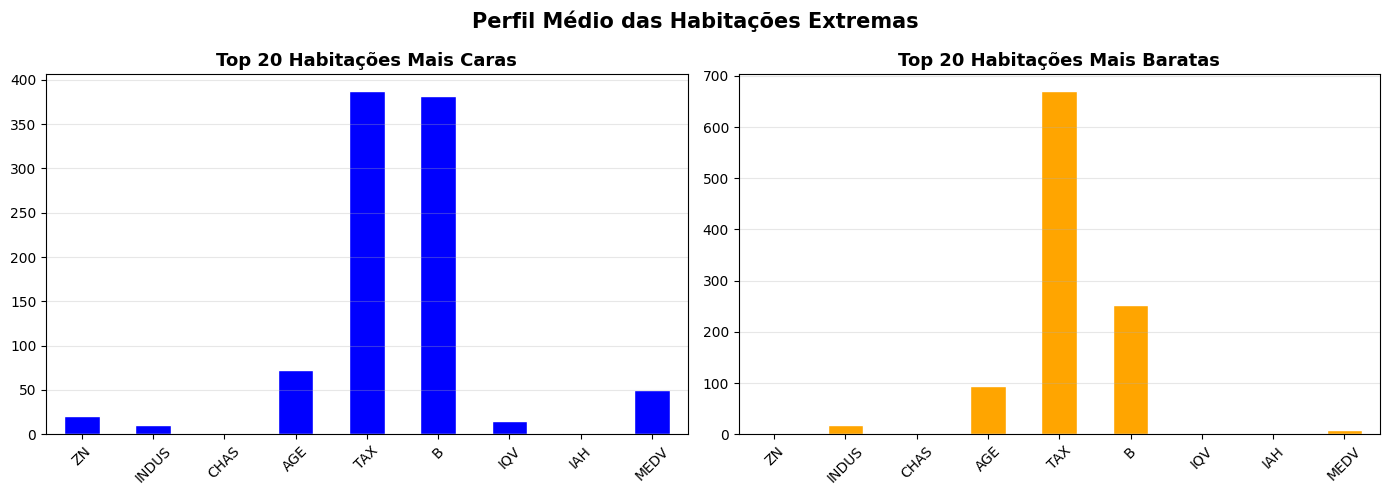

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dados, titulo, cor in [
    (axes[0], top_caros,   'Top 20 Habitações Mais Caras',   'blue'),
    (axes[1], top_baratos, 'Top 20 Habitações Mais Baratas', 'orange')
]:
    dados.mean().plot(kind='bar', ax=ax, color=cor, edgecolor='white')
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Perfil Médio das Habitações Extremas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('habitacoes_extremas.png', dpi=150, bbox_inches='tight')
plt.show()

#### Conclusões:
As habitações mais caras apresentam `IQV` e `IAH` substancialmente superiores, habitações mais recentes e menor presença industrial. As habitações mais baratas concentram-se em bairros com elevada industrialização, habitações antigas e piores condições de qualidade de vida, confirmando que os fatores socioeconómicos e ambientais são determinantes na formação do preço.

## 4. Verificação dos Objetivos SMART
(Natacha Zhang)

In [21]:
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final   = r2_score(y_test, y_pred_final)
sil_final  = silhouette_score(
    X_cl_test,
    AgglomerativeClustering(n_clusters=2, linkage='complete', metric='euclidean').fit_predict(X_cl_test)
)

print('VERIFICAÇÃO DOS OBJETIVOS SMART')
print(f'  SMART 1 | R2 > 0.80    | Obtido: {r2_final:.4f} | {"CUMPRIDO" if r2_final > 0.80 else "NAO CUMPRIDO"}')
print(f'  SMART 1 | RMSE < 3.500 | Obtido: {rmse_final:.4f} | {"CUMPRIDO" if rmse_final < 3.50 else "PROXIMO DO LIMIAR"}')
print(f'  SMART 2 | Sil. > 0.50  | Obtido: {sil_final:.4f} | {"CUMPRIDO" if sil_final > 0.50 else "NAO CUMPRIDO"}')

print()
print('Modelo Regressão : Random Forest (n_estimators=100, random_state=42)')
print('Modelo Clustering: Agglomerative Clustering (linkage=complete, n_clusters=2)')

VERIFICAÇÃO DOS OBJETIVOS SMART
  SMART 1 | R2 > 0.80    | Obtido: 0.8267 | CUMPRIDO
  SMART 1 | RMSE < 3.500 | Obtido: 3.5936 | PROXIMO DO LIMIAR
  SMART 2 | Sil. > 0.50  | Obtido: 0.7363 | CUMPRIDO

Modelo Regressão : Random Forest (n_estimators=100, random_state=42)
Modelo Clustering: Agglomerative Clustering (linkage=complete, n_clusters=2)


#### Conclusão Final:
O **Objetivo SMART 1** foi parcialmente cumprido: o R²=0.83 supera o limiar mínimo (>0.80), contudo o RMSE=3.59 fica ligeiramente acima dos 3.500$ definidos. O **Objetivo SMART 2** foi integralmente cumprido com Silhouette=0.74 no teste, largamente superior ao critério (>0.50), confirmado pelo Bootstrap com IC95%=[0.53, 0.76]. As principais limitações são a dimensão reduzida do dataset (506 observações) e a natureza histórica dos dados (1978).